<a href="https://colab.research.google.com/github/code-with-anchal01/ML-project-foundation/blob/main/insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('/content/insurance.csv')


In [ ]:
df


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


### EDA

In [ ]:
df.shape

(1338, 7)

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

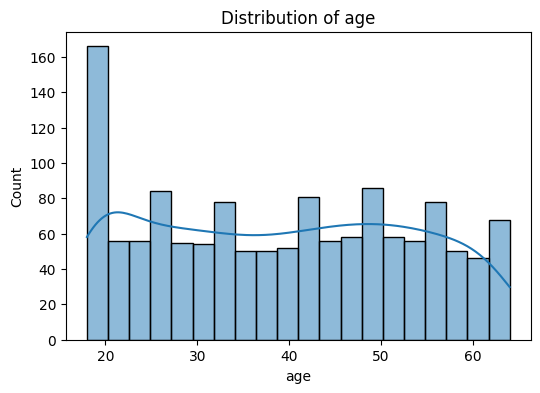

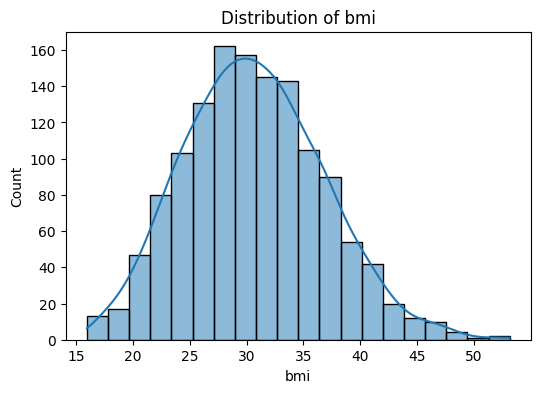

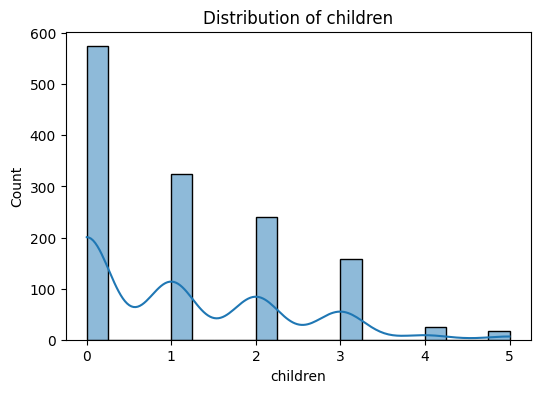

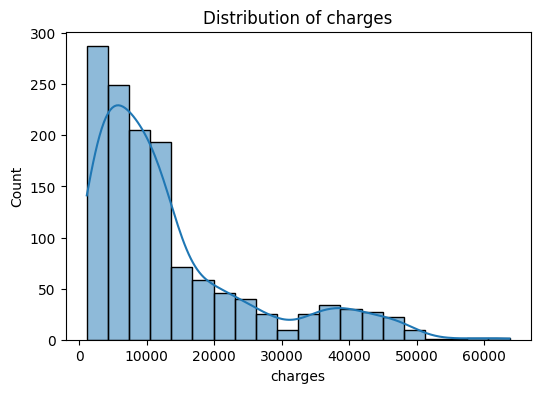

In [ ]:
numeric_columns=['age', 'bmi', 'children', 'charges']
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins = 20)
    plt.xlabel(col)
    plt.title(f'Distribution of {col}')
    plt.show()

<Axes: xlabel='children', ylabel='count'>

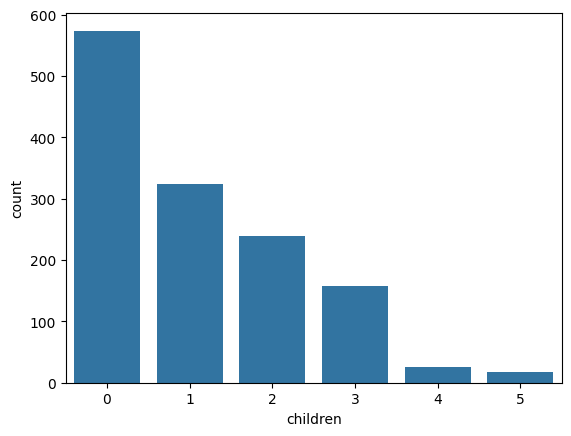

In [ ]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

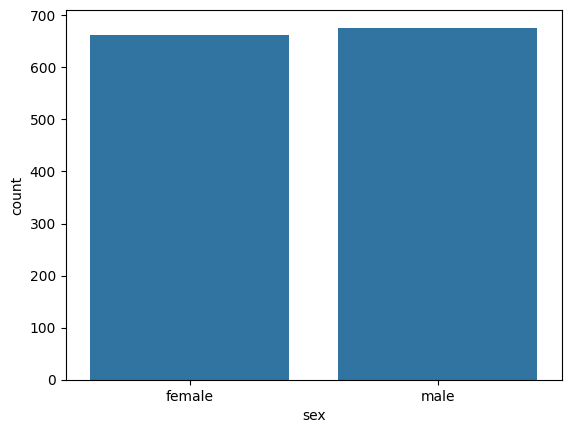

In [ ]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

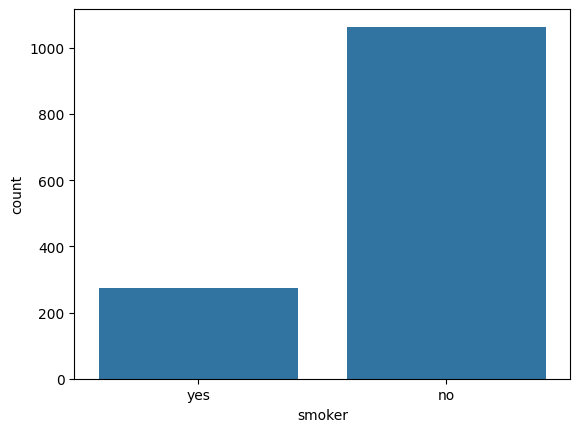

In [ ]:
sns.countplot(x=df['smoker'])

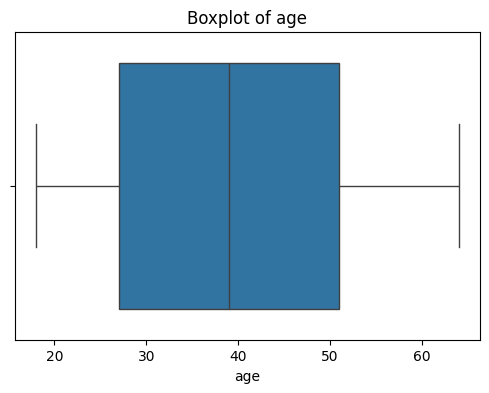

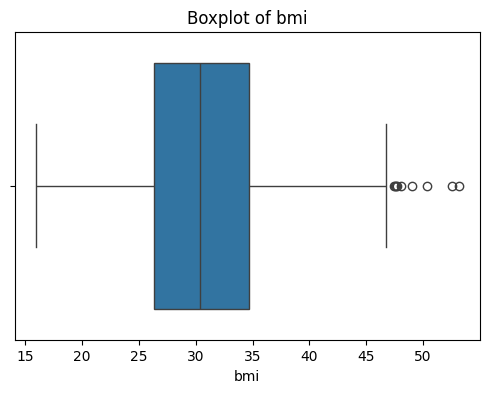

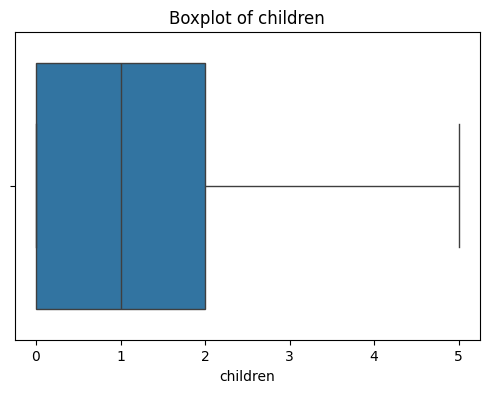

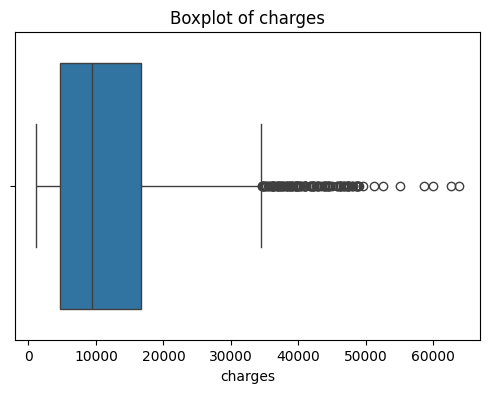

In [ ]:
for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x= df[col])
    plt.xlabel(col)
    plt.title(f'Boxplot of {col}')
    plt.show()

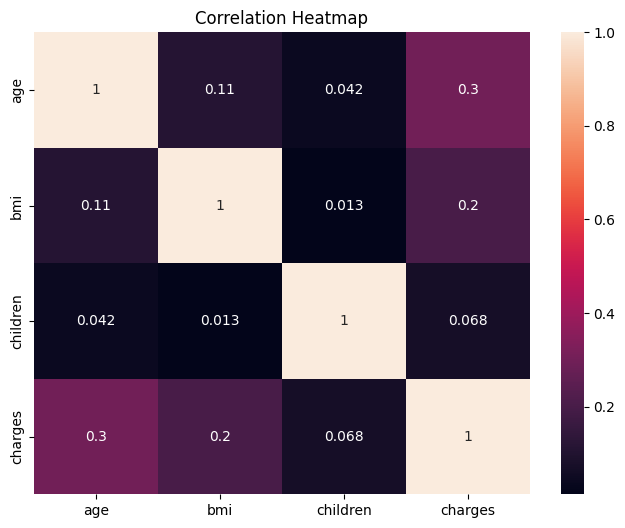

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.title('Correlation Heatmap')
plt.show()

*DATA CLEANING AND PREPROCESSING*

In [ ]:
df_cleaned=df.copy()

In [ ]:
df_cleaned.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df_cleaned.shape

(1338, 7)

In [ ]:
#Remove duplicates
df_cleaned.drop_duplicates(inplace=True)

In [ ]:
df_cleaned.shape

(1337, 7)

In [ ]:
df_cleaned.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df_cleaned.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [ ]:
df_cleaned['sex'].value_counts()

,count
sex,
male,675
female,662


In [ ]:
#label encoding
df_cleaned['sex']=df_cleaned['sex'].map({"male":0,"female":1})

In [ ]:
df_cleaned['smoker'].value_counts()

,count
smoker,
no,1063
yes,274


In [ ]:
df_cleaned['smoker']=df_cleaned['smoker'].map({"yes":0,"no":1})

In [ ]:
df_cleaned

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,0,southwest,16884.92400
1,18,0,33.770,1,1,southeast,1725.55230
2,28,0,33.000,3,1,southeast,4449.46200
3,33,0,22.705,0,1,northwest,21984.47061
4,32,0,28.880,0,1,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,1,northwest,10600.54830
1334,18,1,31.920,0,1,northeast,2205.98080
1335,18,1,36.850,0,1,southeast,1629.83350
1336,21,1,25.800,0,1,southwest,2007.94500


In [ ]:
df_cleaned.rename(columns={
    'sex':'Gender',
    'smoker':'Smoker',
    'region':'Location'}
,inplace = True)

In [ ]:
df_cleaned.head()

,age,Gender,bmi,children,Smoker,Location,charges
0,19,1,27.900,0,0,southwest,16884.92400
1,18,0,33.770,1,1,southeast,1725.55230
2,28,0,33.000,3,1,southeast,4449.46200
3,33,0,22.705,0,1,northwest,21984.47061
4,32,0,28.880,0,1,northwest,3866.85520


In [ ]:
df['region'].value_counts()

,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


In [ ]:
# df_cleaned=df_cleaned.astype({'Location':'category'})

In [ ]:
df_cleaned

,age,Gender,bmi,children,Smoker,Location,charges
0,19,1,27.900,0,0,southwest,16884.92400
1,18,0,33.770,1,1,southeast,1725.55230
2,28,0,33.000,3,1,southeast,4449.46200
3,33,0,22.705,0,1,northwest,21984.47061
4,32,0,28.880,0,1,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,0,30.970,3,1,northwest,10600.54830
1334,18,1,31.920,0,1,northeast,2205.98080
1335,18,1,36.850,0,1,southeast,1629.83350
1336,21,1,25.800,0,1,southwest,2007.94500


In [ ]:
import pandas as pd

if 'Location' in df_cleaned.columns:
    df_cleaned = pd.get_dummies(df_cleaned, columns=['Location'])
    print("Dummy variables for 'Location' created successfully.")
else:
    print("Column 'Location' not found. It might have already been processed.")

df_cleaned.head()

Dummy variables for 'Location' created successfully.


,age,Gender,bmi,children,Smoker,charges,Location_northeast,Location_northwest,Location_southeast,Location_southwest
0,19,1,27.900,0,0,16884.92400,False,False,False,True
1,18,0,33.770,1,1,1725.55230,False,False,True,False
2,28,0,33.000,3,1,4449.46200,False,False,True,False
3,33,0,22.705,0,1,21984.47061,False,True,False,False
4,32,0,28.880,0,1,3866.85520,False,True,False,False


In [ ]:
# Convert boolean columns to integer (1 and 0)
for col in df_cleaned.columns:
    if col.startswith('Location_'):
        df_cleaned[col] = df_cleaned[col].astype(int)

df_cleaned.head()

,age,Gender,bmi,children,Smoker,charges,Location_northeast,Location_northwest,Location_southeast,Location_southwest
0,19,1,27.900,0,0,16884.92400,0,0,0,1
1,18,0,33.770,1,1,1725.55230,0,0,1,0
2,28,0,33.000,3,1,4449.46200,0,0,1,0
3,33,0,22.705,0,1,21984.47061,0,1,0,0
4,32,0,28.880,0,1,3866.85520,0,1,0,0


**Feature engineering and extraction**

<Axes: xlabel='bmi', ylabel='Count'>

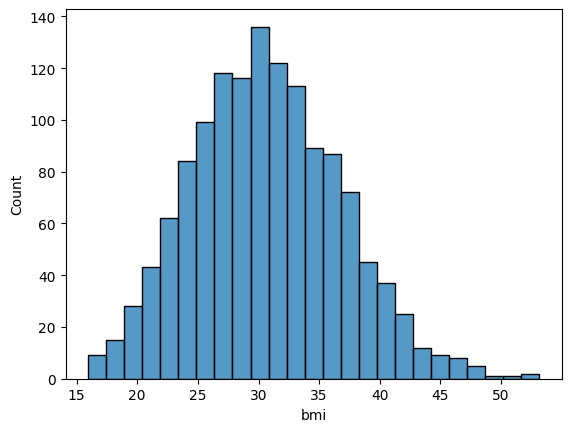

In [ ]:
sns.histplot(x=df['bmi'])

In [ ]:
df_cleaned['bmi_category']=pd.cut(
    df_cleaned['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['Underweight','Normal','Overweight','Obese']

)

In [ ]:
df_cleaned

,age,Gender,bmi,children,Smoker,charges,Location_northeast,Location_northwest,Location_southeast,Location_southwest,bmi_category
0,19,1,27.900,0,0,16884.92400,0,0,0,1,Overweight
1,18,0,33.770,1,1,1725.55230,0,0,1,0,Obese
2,28,0,33.000,3,1,4449.46200,0,0,1,0,Obese
3,33,0,22.705,0,1,21984.47061,0,1,0,0,Normal
4,32,0,28.880,0,1,3866.85520,0,1,0,0,Overweight
...,...,...,...,...,...,...,...,...,...,...,...
1333,50,0,30.970,3,1,10600.54830,0,1,0,0,Obese
1334,18,1,31.920,0,1,2205.98080,1,0,0,0,Obese
1335,18,1,36.850,0,1,1629.83350,0,0,1,0,Obese
1336,21,1,25.800,0,1,2007.94500,0,0,0,1,Overweight


In [ ]:
#one hot coding
if 'bmi_category' in df_cleaned.columns:
    df_cleaned=pd.get_dummies(df_cleaned,columns=['bmi_category'],drop_first=True)
else:
    print("Column 'bmi_category' not found. It might have already been dummified or dropped.")

In [ ]:
df_cleaned=df_cleaned.astype(int)

In [ ]:
df_cleaned.head()

,age,Gender,bmi,children,Smoker,charges,Location_northeast,Location_northwest,Location_southeast,Location_southwest,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,19,1,27,0,0,16884,0,0,0,1,0,1,0
1,18,0,33,1,1,1725,0,0,1,0,0,0,1
2,28,0,33,3,1,4449,0,0,1,0,0,0,1
3,33,0,22,0,1,21984,0,1,0,0,1,0,0
4,32,0,28,0,1,3866,0,1,0,0,0,1,0


In [ ]:
df_cleaned.columns

Index(['age', 'Gender', 'bmi', 'children', 'Smoker', 'charges',
       'Location_northeast', 'Location_northwest', 'Location_southeast',
       'Location_southwest', 'bmi_category_Normal', 'bmi_category_Overweight',
       'bmi_category_Obese'],
      dtype='object')

In [ ]:
#Standard Scalar
from sklearn.preprocessing import StandardScaler
cols=['age','bmi','children']
scaler= StandardScaler()
df_cleaned[cols]=scaler.fit_transform(df_cleaned[cols])


In [ ]:
from scipy.stats import pearsonr
import pandas as pd
# Pearson Correlation Calculation
# --------------------------------

# List of features to check against target
selected_features = [
    'age', 'bmi', 'children', 'Gender', 'Smoker',
    'Location_northeast', 'Location_northwest', 'Location_southeast', 'Location_southwest',
    'bmi_category_Normal', 'bmi_category_Overweight', 'bmi_category_Obese'
]

correlations = {
    feature: pearsonr(df_cleaned[feature], df_cleaned['charges'])[0]
    for feature in selected_features
}

correlation_df = pd.DataFrame(
    list(correlations.items()),
    columns=['Feature', 'Pearson Correlation']
)

correlation_df = correlation_df.sort_values(
    by='Pearson Correlation',
    ascending=False
)

In [ ]:
cat_fetures=['Gender','Smoker','Location_northeast','Location_northwest','Location_southeast','Location_southwest','bmi_category_Normal','bmi_category_Overweight','bmi_category_Obese']


In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

alpha = 0.05
df_cleaned['charges_bin']=pd.cut(df_cleaned['charges'],bins=4,labels=False)
chi2_results = {}

for col in cat_fetures:
    contingency_table = pd.crosstab(df_cleaned[col], df_cleaned['charges_bin'])
    chi2_stat, p_val,_,_ = chi2_contingency(contingency_table)
    decision = 'Reject Null(Keep Feature)' if p_val<alpha else "Accept Null(Drop Feature)"
    chi2_results[col]={
        'chi2_statistic': chi2_stat,
        'p_value':p_val,
        'decision':decision
    }

chi2_df = pd.DataFrame(chi2_results).T
chi2_df = chi2_df.sort_values(by='p_value')
chi2_df

,chi2_statistic,p_value,decision
Smoker,918.577819,0.0,Reject Null(Keep Feature)
bmi_category_Obese,165.631264,0.0,Reject Null(Keep Feature)
bmi_category_Overweight,82.014303,0.0,Reject Null(Keep Feature)
bmi_category_Normal,39.526341,0.0,Reject Null(Keep Feature)
Location_southeast,13.502398,0.003667,Reject Null(Keep Feature)
Gender,11.212656,0.01063,Reject Null(Keep Feature)
Location_southwest,6.611919,0.085352,Accept Null(Drop Feature)
Location_northwest,5.61161,0.132113,Accept Null(Drop Feature)
Location_northeast,2.395273,0.494515,Accept Null(Drop Feature)


In [ ]:
features_to_keep = chi2_df[chi2_df['decision'] == 'Reject Null(Keep Feature)'].index.tolist()

# Include 'age', 'bmi', 'children', and 'charges' as they are important numerical features or the target variable
final_features = ['age', 'bmi', 'children', 'charges'] + features_to_keep

# Ensure no duplicate features in the final list
final_features = list(set(final_features))

final_df = df_cleaned[final_features]
display(final_df.head())

,Smoker,age,bmi_category_Obese,bmi_category_Normal,charges,Gender,children,Location_southeast,bmi,bmi_category_Overweight
0,0,-1.440418,0,0,16884,1,-0.909234,0,-0.517949,1
1,1,-1.511647,1,0,1725,0,-0.079442,1,0.462463,0
2,1,-0.799350,1,0,4449,0,1.580143,1,0.462463,0
3,1,-0.443201,0,1,21984,0,-0.909234,0,-1.334960,0
4,1,-0.514431,0,0,3866,0,-0.909234,0,-0.354547,1
